<a href="https://colab.research.google.com/github/nataliaespector/CEIA-VisionPorComputadoraII/blob/main/4_Modelo_DenseNet121.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final Visión por Computadora II - CEIA - UBA
## Modelo: DenseNet121
### Dataset seleccionado: Chest CT-Scan images Dataset (Kaggle).

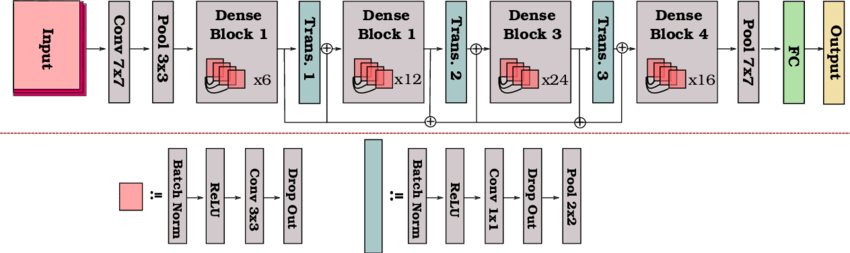

*Imagen tomada de: https://www.kaggle.com/code/iamtapendu/introduction-to-densenet-121*

**Resumen**

En este notebook se presenta el entrenamiento realizado con la arquitectura **DenseNet121** con pesos entrenados con el dataset **ImageNet**, y se comparó su desempeño con el modelo *baseline* correspondiente a la VGG16.

Al igual que en el caso anterior, se utilizó el dataset procesado *(clean)* y se aplicaron técnicas de *data augmentation*, basadas en las transformaciones propuestas durante el EDA.

Si bien se reporta la *accuracy* como referencia, se priorizó el análisis de las métricas *F1-macro* y *recall* por su mayor relevancia clínica. Además, se analizó detalladamente la matriz de confusión para interpretar el comportamiento del modelo por clase.

Se realizaron múltiples experimentos variando los parámetros de entrenamiento. En este notebook se presenta el entrenamiento con el que se obtuvieron los mejores resultados, y un resumen de las pruebas realizadas.

Para la arquitectura **DenseNet121** se obtuvo una **accuracy de 0.92**, un **F1-macro de 0.93** y un **recall-macro de 0.94**. Se obtuvo una amplia mejora en el desempeño, en comparación al modelo *baseline* VGG16 que presentaba una *accuracy* de 0.64, y *F1-macro* y *recall-macro* de *0.68*.

Además, estos resultados tienen una gran relevancia clínica, ya que el modelo presenta muy leves confusiones entre clases tumorales, pero logra diferenciar las imágenes normales de las patológicas en prácticamente todos los casos (recall = 1). Esto está alineado con el objetivo clínico para este tipo de modelos, que es disminuir los falsos negativos.

## Importar librerías

In [1]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#!pip install torchmetrics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import random
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torchvision
import torchsummary
#import torchmetrics
from torch.utils.tensorboard import SummaryWriter

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

## Carga de datos

En caso de correr en Colab, leer carpeta Data_Clean cargada en Drive y verificar su contenido

In [4]:
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

In [ ]:
if IN_COLAB:
    data_dir = '/content/drive/MyDrive/Data_Clean'
else:
    data_dir = './Data_Clean'

if os.path.exists(data_dir):
    print(f"Contenido de {data_dir}:")
    for item in os.listdir(data_dir):
        print(item)
else:
    print(f"El directorio {data_dir} no existe.")

Contenido de /content/drive/MyDrive/Data_Clean:
train
valid
test
vgg16_baseline_best.pth
DenseNet121_best.pth


In [ ]:
data_dir=Path(data_dir)

## Carga de datos con ImageDataGenerator

Se utiliza la arquitectura de VGG16 con pesos entrenados con el dataset ImageNet, disponible en el módulo *models* de Pytorch.

In [ ]:
random_seed = 42
torch.manual_seed(random_seed)

Definición de transformaciones a utilizar para Data Augmentation (propuestas durante el EDA):

* Conversión a **escala de grises**, acorde a la naturaleza de las imágenes de tomografía computada.

* Unificación del **tamaño de imagen** y uso de formatos cuadrados.

* Aplicación de **transformaciones espaciales leves**: rotación de ±10° y variaciones de escala en el rango 0.9–1.1.

* **Flip horizontal aleatorio** (se evita el vertical, que invertiría la orientación anatómica del paciente).

* Variaciones leves de **brillo y contraste**, y **ruido gaussiano suave**, para simular diferencias entre equipos y protocolos de adquisición.

* **Normalización** con los valores de mean y std de ImageNet, necesaria para el uso de pesos preentrenados.

In [ ]:
ANCHO_IMAGENES = 224
ALTO_IMAGENES = 224
CANTIDAD_CLASES = 4

# Definir transformaciones para el train set
train_transforms = transforms.Compose([
                        transforms.Grayscale(num_output_channels=3), # 3 canales porque es lo que espera la VGG
                        transforms.Resize(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
                        transforms.RandomRotation(degrees=10),
                        transforms.RandomHorizontalFlip(0.5),
                        transforms.RandomResizedCrop(size=(ANCHO_IMAGENES, ALTO_IMAGENES), scale=(0.9, 1.1)),
                        transforms.ColorJitter(brightness=0.1, contrast=0.1),
                        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                      ])

# Definir transformaciones para valid y test set
valid_test_transforms = transforms.Compose([
                    transforms.Grayscale(num_output_channels=3),
                    transforms.Resize(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
                    transforms.CenterCrop(size=(ANCHO_IMAGENES, ALTO_IMAGENES)),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                  ])

Preparación de datos con ImageFolder - DataLoaders

In [ ]:
from torchvision.datasets import ImageFolder

# Crear datasets con ImageFolder
train_dataset = datasets.ImageFolder(root=data_dir / "train", transform=train_transforms)

valid_dataset = datasets.ImageFolder(root=data_dir / "valid", transform=valid_test_transforms)

test_dataset = datasets.ImageFolder(root=data_dir / "test", transform=valid_test_transforms)

batch_size=32

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_dataset, batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=True)

class_names = train_dataset.classes
num_classes = len(class_names)

# Renombrar las clases
class_name_mapping = {
    'adenocarcinoma_left': 'Adenocarcinoma',
    'large.cell.carcinoma_left': 'Large Cell Carcinoma',
    'normal': 'Normal',
    'squamous.cell.carcinoma_left': 'Squamous Cell Carcinoma'
}
class_names = [class_name_mapping.get(name, name) for name in class_names]

print("Clases:", class_names)
print(f"Imágenes train: {len(train_dataset)}")
print(f"Imágenes valid: {len(valid_dataset)}")
print(f"Imágenes test : {len(test_dataset)}")

Clases: ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
Imágenes train: 577
Imágenes valid: 126
Imágenes test : 128


## Modelo: DenseNet121 preentrenada en ImageNet

In [ ]:
from torchvision.models import DenseNet121_Weights

weights = DenseNet121_Weights.IMAGENET1K_V1
densenet121_model = models.densenet121(weights=weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
densenet121_model.to(device)

print(densenet121_model)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

Congelar capas convolucionales del modelo base

In [ ]:
for param in densenet121_model.parameters():
    param.requires_grad = False

**Fine-tuning parcial**: se utiliza para que la red "desaprenda" lo que es muy específico de ImageNet y pueda especializarse en patrones de imágenes de tomografía. Para esto, además de entrenar el clasificador final, se reentrena también el último bloque convolucional de DenseNet121, correspondiente a las capas *denseblock4* y *norm5*.

In [ ]:
# Descongelar solo denseblock4 y norm5
for name, param in densenet121_model.features.named_parameters():
    if "denseblock4" in name or "norm5" in name:
        param.requires_grad = True

Reemplazar última capa fully-connected del clasificador

In [ ]:
in_features = densenet121_model.classifier.in_features
densenet121_model.classifier = torch.nn.Linear(in_features, CANTIDAD_CLASES)

densenet121_model.to(device)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

Solo entrenar las capas con requires_grad=True (en este caso, *denseblock4*, *norm5* y el clasificador)

In [ ]:
params_to_update = [p for p in densenet121_model.parameters() if p.requires_grad]

Ver cantidad de parámetros entrenables

In [ ]:
total_params = sum(p.numel() for p in densenet121_model.parameters())
trainable_params = sum(p.numel() for p in densenet121_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

Total parameters: 6,957,956
Trainable parameters: 2,164,228
Frozen parameters: 4,793,728


## Entrenamiento de la red

Definir optimizador y función de pérdida

In [ ]:
num_epochs = 60
lr = 5e-5
weight_decay = 1e-4

loss = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params_to_update, lr=lr, weight_decay=weight_decay)

# Scheduler: reduce el LR si la valid loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

Definir función de entrenamiento por época y evaluación



In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

Entrenamiento (se agrega *early stopping*)

In [ ]:
import time

patience = 7
min_delta = 1e-3

best_valid_loss = float("inf")
best_model_wts = None
epochs_no_improve = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": [],
}

for epoch in range(num_epochs):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        densenet121_model, train_loader, loss, optimizer, device
    )
    valid_loss, valid_acc = evaluate(
        densenet121_model, valid_loader, loss, device
    )

    scheduler.step(valid_loss)

    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["valid_loss"].append(valid_loss)
    history["valid_acc"].append(valid_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- {elapsed:.1f}s | "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
          f"Valid loss: {valid_loss:.4f}, acc: {valid_acc:.4f}")

    # Guardar el mejor modelo según valid_loss + early stopping
    if valid_loss < best_valid_loss - min_delta:
        best_valid_loss = valid_loss
        best_model_wts = densenet121_model.state_dict().copy()
        epochs_no_improve = 0
        print("  -> Nuevo mejor modelo guardado (mejora valid loss)")
    else:
        epochs_no_improve += 1
        print(f"  -> Sin mejora en valid_loss ({epochs_no_improve}/{patience})")

    if epochs_no_improve >= patience:
        print("  -> Early stopping activado")
        break

# Cargar mejores pesos
if best_model_wts is not None:
    densenet121_model.load_state_dict(best_model_wts)

Epoch 1/60 - 16.1s | Train loss: 1.2836, acc: 0.3605 | Valid loss: 1.1478, acc: 0.5952
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 2/60 - 12.3s | Train loss: 1.0580, acc: 0.5650 | Valid loss: 1.0141, acc: 0.5556
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 3/60 - 13.2s | Train loss: 0.9466, acc: 0.6551 | Valid loss: 0.9040, acc: 0.6746
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 4/60 - 14.3s | Train loss: 0.8563, acc: 0.6759 | Valid loss: 0.8174, acc: 0.7381
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 5/60 - 12.9s | Train loss: 0.7774, acc: 0.7106 | Valid loss: 0.7577, acc: 0.7460
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 6/60 - 12.4s | Train loss: 0.7069, acc: 0.7504 | Valid loss: 0.6936, acc: 0.7778
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 7/60 - 12.9s | Train loss: 0.6536, acc: 0.7972 | Valid loss: 0.6464, acc: 0.7460
  -> Nuevo mejor modelo guardado (mejora valid loss)
Epoch 8/60 - 13.0s |

Graficar curva de pérdida y accuracy

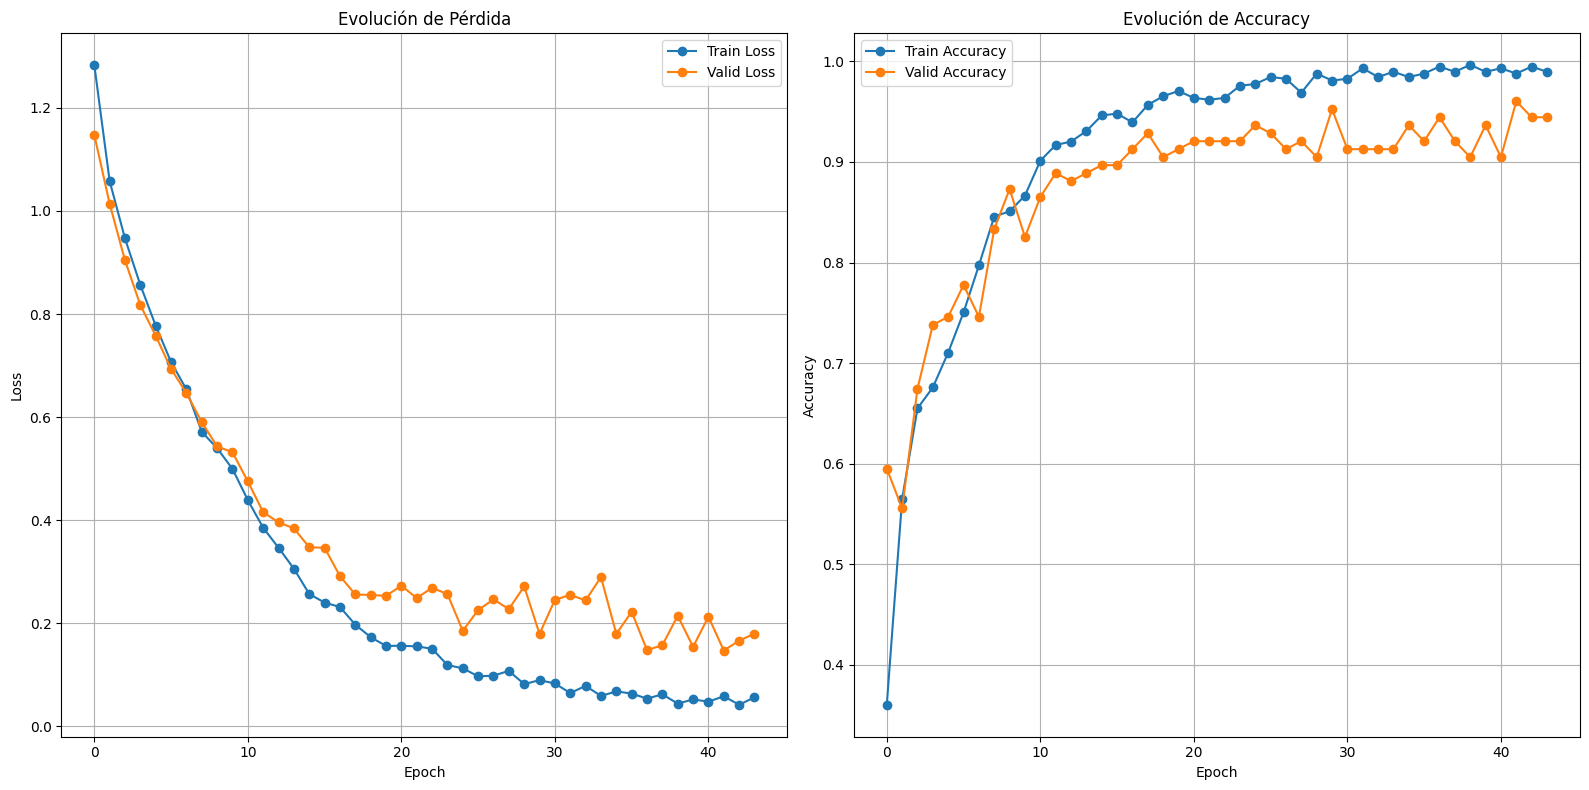

In [ ]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["valid_loss"], label="Valid Loss", marker="o")

plt.title("Evolución de Pérdida")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Accuracy", marker="o")
plt.plot(history["valid_acc"], label="Valid Accuracy", marker="o")

plt.title("Evolución de Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Resultados: evaluación en test

Pérdida y accuracy

In [ ]:
test_loss, test_acc = evaluate(densenet121_model, test_loader, loss, device)
print("\nRESULTADOS FINALES EN TEST")
print(f"Test loss: {test_loss:.4f}")
print(f"Test acc : {test_acc:.4f}")


RESULTADOS FINALES EN TEST
Test loss: 0.2470
Test acc : 0.9219


Classification report y matriz de confusión


Classification report (TEST) - DenseNet121:
                         precision    recall  f1-score   support

         Adenocarcinoma       0.96      0.88      0.92        51
   Large Cell Carcinoma       0.84      0.96      0.90        28
                 Normal       0.91      1.00      0.95        10
Squamous Cell Carcinoma       0.95      0.92      0.94        39

               accuracy                           0.92       128
              macro avg       0.91      0.94      0.93       128
           weighted avg       0.93      0.92      0.92       128



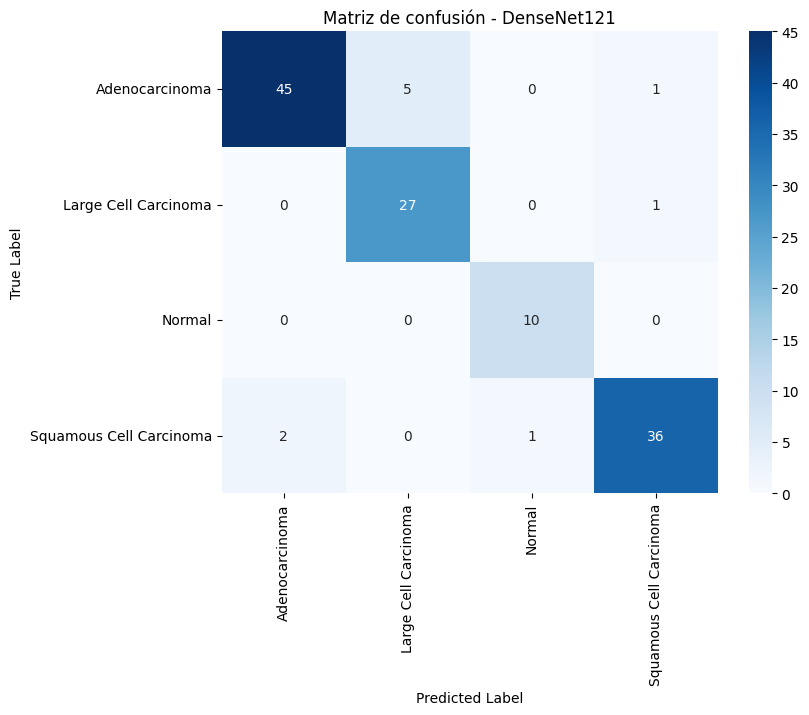

In [ ]:
def get_all_preds_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

y_pred, y_true = get_all_preds_and_labels(densenet121_model, test_loader, device)

print("\nClassification report (TEST) - DenseNet121:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Matriz de confusión - DenseNet121')
plt.show()

El modelo alcanzó una **accuracy de 0.92**, un **F1-macro de 0.93** y un **recall-macro de 0.94**, mostrando una excelente capacidad de discriminación entre las cuatro clases analizadas (Adenocarcinoma, Large Cell Carcinoma, Squamous Cell Carcinoma y Normal).

Además, el desempeño obtenido con la arquitectura **DenseNet121** resulta claramente superador respecto del modelo baseline basado en **VGG16**, aun entrenando una cantidad muy inferior de parámetros:

**Comparación de modelos:**

* VGG16 baseline:
  * Parámetros entrenables ≈ 25M
  * F1-macro = 0.68

* DenseNet121 con *fine-tuning* parcial (denseblock4 + norm5):
  * Parámetros entrenables ≈ 2.16M
  * F1-macro = 0.93

La **matriz de confusión** muestra que:

* Las **clases tumorales** se reconocen correctamente en la amplia mayoría de los casos, aunque todavía existen confusiones entre algunos subtipos, lo que podría deberse a una similitud entre las imágenes de estos casos.

* La clase **Normal** se clasifica con gran precisión (recall = 1.0), lo que es muy relevante desde el punto de vista clínico, ya que minimiza los falsos negativos.

Estos resultados tienen una fuerte importancia clínica: el modelo presenta muy leves confusiones entre clases tumorales, pero logra identificar las imágenes normales frente a las patológicas en prácticamente todos los casos.
Ese es el comportamiento deseable en un sistema de apoyo para el diagnóstico, ya que el objetivo principal es poder diferenciar estudios sanos de sospechosos, mientras que el diagnóstico definitivo quedará a cargo de un médico especialista o se confirmará mediante estudios complementarios (por ejemplo, una biopsia).

## Guardar el modelo entrenado

In [ ]:
model_path = data_dir / "DenseNet121_best.pth"
torch.save(densenet121_model.state_dict(), model_path)
print(f"\nModelo guardado en: {model_path}")


Modelo guardado en: /content/drive/MyDrive/Data_Clean/DenseNet121_best.pth


## Resumen de entrenamientos

Inicialmente se entrenó la arquitectura **DenseNet121** del mismo modo que se había hecho con **VGG16**: entrenando **únicamente el clasificador final**. Para este caso (entrenamiento 1) el desempeño de la red fue inferior al de la VGG16.

Revisando la bibliografía, se observó que **DenseNet121**, debido a sus **conexiones densas** genera representaciones muy ricas pero también **altamente especializadas** para el dominio en el que fue entrenada (ImageNet). Por esta razón, y por tratarse de un *dataset* con pocos datos, la red podía estar quedando demasiado sesgada a las representaciones originales, dificultando su adaptación a las imágenes médicas.

Por esta razón se realizó un **fine-tuning parcial** (entrenamiento 2), con el objetivo de que la red "desaprenda" parte de lo específico de ImageNet y pueda adaptarse a los patrones propios de las imágenes de tomografía. Para esto, además de entrenar el clasificador final, se reentrenó también el **último bloque convolucional** de DenseNet121, correspondiente a las capas *denseblock4* y *norm5*. Este enfoque mejoró considerablemente los resultados obtenidos.

A partir de esta modificación, se evaluaron **ajustes de learning rate** y **número de épocas**, y se incorporó **early stopping** para evitar sobreentrenamiento y reducir los tiempos de ejecución.

La mejor configuración se obtuvo con un **learning rate de 5·10⁻⁵ y fine-tuning parcial** de las capas profundas de DenseNet121. Reducciones adicionales del LR no aportaron mejoras significativas.

A continuación se presenta un resumen de los entrenamientos realizados y sus resultados:

| Nº | Epochs | Capas descongeladas      | Early Stopping | Learning rate | Accuracy | Macro F1 | Macro Recall | Notas                                |
|----|--------|---------------------------|----------------|----------------|----------|-----------|----------------|--------------------------------------|
| 1  | 60     | solo clasificador (= VGG16)        | No             | 1e-4        | 0.5625     | 0.56      | 0.57           | Baseline VGG16                       |
| 2  | 40     | clasif + denseblock4 y norm5       | No             | 1e-4        | 0.9297   | 0.93      | 0.95           | Primer fine-tuning (sin ES)         |
| 3  | 24     | clasif + denseblock4 y norm5       | Sí             | 1e-4        | 0.9141   | 0.91      | 0.94           | Fine-tuning + ES                    |
| 4  | 47     | clasif + denseblock4 y norm5       | Sí             | 5e-5        | **0.9453** | **0.95**   | **0.96**        | **Mejor desempeño global**            |
| 5  | 10     | clasif + denseblock4 y norm5       | Sí             | 1e-3        | 0.9219   | 0.93      | 0.94           | LR muy alto → descenso de valid loss no uniforme          |
